In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import os
import json
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
# Set project paths
PROJECT_DIR = "/content/drive/MyDrive/DLP2"

PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

In [ ]:
# Load processed dataset
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_val = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))

y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_val = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

with open(os.path.join(PROCESSED_DIR, "activity_labels.json"), "r") as f:
    activity_labels = json.load(f)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)
print(activity_labels)

X_train: (5881, 128, 9)
X_val: (1471, 128, 9)
X_test: (2947, 128, 9)
y_train: (5881,)
y_val: (1471,)
y_test: (2947,)
{'0': 'WALKING', '1': 'WALKING_UPSTAIRS', '2': 'WALKING_DOWNSTAIRS', '3': 'SITTING', '4': 'STANDING', '5': 'LAYING'}


In [ ]:
# Set basic constants
TIME_STEPS = X_train.shape[1]
NUM_CHANNELS = X_train.shape[2]
NUM_CLASSES = len(activity_labels)

INPUT_SHAPE = (TIME_STEPS, NUM_CHANNELS)

print("Input shape:", INPUT_SHAPE)
print("Number of classes:", NUM_CLASSES)

Input shape: (128, 9)
Number of classes: 6


In [ ]:
# Build CNN-only model
def build_cnn_baseline(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(
            filters=128,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling1D(pool_size=2),

        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model


cnn_model = build_cnn_baseline(INPUT_SHAPE, NUM_CLASSES)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,142 (137.27 KB)

 Trainable params: 35,142 (137.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Add callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(MODELS_DIR, "cnn_baseline_best.keras"),
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
# Train the model
history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7800 - loss: 0.6865 - val_accuracy: 0.9320 - val_loss: 0.2043
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9390 - loss: 0.1630 - val_accuracy: 0.9572 - val_loss: 0.1371
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9492 - loss: 0.1315 - val_accuracy: 0.9470 - val_loss: 0.1396
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9488 - loss: 0.1212 - val_accuracy: 0.9565 - val_loss: 0.1159
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9505 - loss: 0.1146 - val_accuracy: 0.9565 - val_loss: 0.1052
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9529 - loss: 0.1098 - val_accuracy: 0.9524 - val_loss: 0.1078
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9517 - loss: 0.1063 - val_accuracy: 0.9551 - val_loss: 0.0967
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9539 - loss: 0.1018 - val_accuracy: 0.9538 - val_loss

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.5090968012809753
Test Accuracy: 0.9229725003242493


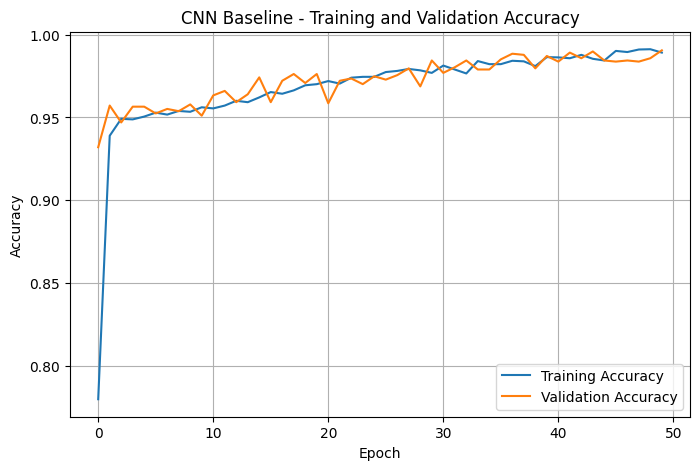

In [ ]:
# Plot accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Baseline - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, "cnn_baseline_accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()

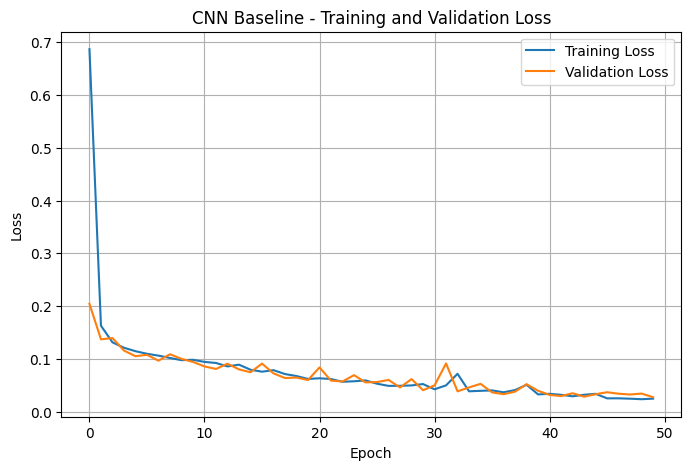

In [ ]:
# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Baseline - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, "cnn_baseline_loss.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Generate predictions
y_pred_probs = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
# Classification report
target_names = [activity_labels[str(i)] for i in range(NUM_CLASSES)]

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4
)

print(report)

                    precision    recall  f1-score   support

           WALKING     0.9958    0.9657    0.9806       496
  WALKING_UPSTAIRS     0.9798    0.9257    0.9520       471
WALKING_DOWNSTAIRS     0.8917    1.0000    0.9428       420
           SITTING     0.8146    0.8411    0.8277       491
          STANDING     0.8617    0.8195    0.8401       532
            LAYING     0.9981    0.9981    0.9981       537

          accuracy                         0.9230      2947
         macro avg     0.9236    0.9250    0.9235      2947
      weighted avg     0.9244    0.9230    0.9230      2947



In [ ]:
with open(os.path.join(RESULTS_DIR, "cnn_baseline_classification_report.txt"), "w") as f:
    f.write(report)

print("Classification report saved.")

Classification report saved.


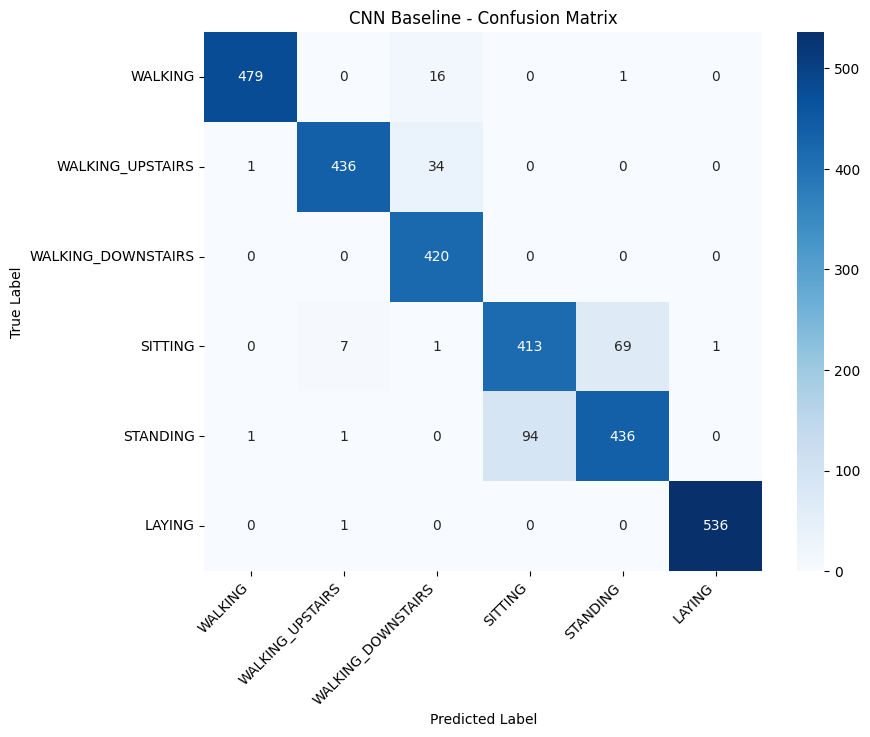

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Baseline - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig(os.path.join(FIGURES_DIR, "cnn_baseline_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Save final model
cnn_model.save(os.path.join(MODELS_DIR, "cnn_baseline_final.keras"))

print("CNN baseline model saved.")

CNN baseline model saved.


In [ ]:
# Save summary results as JSON
cnn_results = {
    "experiment": "Experiment 1 - CNN-only Baseline",
    "model": "Conv1D + MaxPooling1D + Dense",
    "input_shape": list(INPUT_SHAPE),
    "num_classes": NUM_CLASSES,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs_trained": len(history.history["loss"]),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy)
}

with open(os.path.join(RESULTS_DIR, "cnn_baseline_results.json"), "w") as f:
    json.dump(cnn_results, f, indent=4)

cnn_results

{'experiment': 'Experiment 1 - CNN-only Baseline',
 'model': 'Conv1D + MaxPooling1D + Dense',
 'input_shape': [128, 9],
 'num_classes': 6,
 'optimizer': 'Adam',
 'learning_rate': 0.001,
 'batch_size': 64,
 'epochs_trained': 50,
 'test_loss': 0.5090968012809753,
 'test_accuracy': 0.9229725003242493}